In [39]:
# Solo funciona en Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
!ls -la /content/drive/MyDrive/Riesgos/

total 2504
-rw------- 1 root root    1195 Mar 15 13:40 label_encoders.joblib
-rw------- 1 root root    1871 Mar 15 13:40 minmax_scaler.joblib
-rw------- 1 root root 2560393 Mar 15 13:36 riesgo.xlsx


In [41]:
%cd /content/drive/MyDrive/Riesgos/

/content/drive/MyDrive/Riesgos


In [42]:
import pandas as pd


df = pd.read_excel("riesgo.xlsx")
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [43]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Name                      12500 non-null  object 
 2   Age                       12500 non-null  float64
 3   SSN                       12500 non-null  object 
 4   Occupation                12500 non-null  object 
 5   Annual_Income             12500 non-null  float64
 6   Monthly_Inhand_Salary     12500 non-null  float64
 7   Num_Bank_Accounts         12500 non-null  float64
 8   Num_Credit_Card           12500 non-null  float64
 9   Interest_Rate             12500 non-null  int64  
 10  Num_of_Loan               12500 non-null  int64  
 11  Type_of_Loan              11074 non-null  object 
 12  Delay_from_due_date       12500 non-null  float64
 13  Num_of_Delayed_Payment    12500 non-null  float64
 14  Change

In [45]:
# Para borrar columnas específicas se usa drop (no dropna)
df.drop(columns=['Customer_ID', 'Name', 'SSN', 'Type_of_Loan'], axis=1, inplace=True)

# Si además quieres eliminar filas con nulos en las columnas restantes:
df = df.dropna()

df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,12500.0,33.311294,10.760177,14.000000,24.415179,33.000000,41.750000,56.000000
Annual_Income,12500.0,50505.123449,38300.762656,7005.930000,19342.972500,36999.705000,71683.470000,179987.280000
Monthly_Inhand_Salary,12500.0,4198.468568,3187.142979,303.645417,1625.744479,3097.016667,5961.664375,15204.633333
Num_Bank_Accounts,12500.0,5.368828,2.592493,0.000000,3.000000,5.375000,7.000000,10.500000
Num_Credit_Card,12500.0,5.533620,2.066040,0.500000,4.000000,5.000000,7.000000,10.875000
Interest_Rate,12500.0,14.532080,8.741636,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,12500.0,3.532880,2.446442,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000
Num_of_Delayed_Payment,12500.0,13.338642,6.153148,0.000000,9.000000,13.750000,18.175000,26.375000
Changed_Credit_Limit,12500.0,10.465068,6.445141,0.500000,5.493750,9.370000,14.656250,31.115000


In [47]:
df.describe(include='object').T

,count,unique,top,freq
Occupation,12500,15,Lawyer,887
Credit_Mix,12500,3,Standard,5731
Payment_of_Min_Amount,12500,3,Yes,7360
Payment_Behaviour,12500,6,Low_spent_Small_value_payments,3860


In [48]:
df.drop(columns=['Occupation'], axis=1, inplace=True)

In [49]:
# Reindexar el DataFrame para que el índice vuelva a ser 0..n-1
df.reset_index(drop=True, inplace=True)

# Verificar
df.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,...,Bad,1562.91,25.036185,10.458333,Yes,81.797271,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,...,Standard,202.68,50.771467,30.714286,Yes,53.546010,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,...,Good,1030.20,29.610420,15.571429,No,83.438236,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,...,Standard,473.14,43.950325,15.541667,Yes,56.104813,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,...,Good,1233.51,44.397384,17.535714,No,50.146076,355.442408,High_spent_Medium_value_payments,472.781009,1


In [50]:
columnas_object = df.select_dtypes(include=["object"]).columns.tolist()
columnas_numericas = df.select_dtypes(include=["number"]).columns.tolist()

print("Columnas object:")
print(columnas_object)

print("\nColumnas numéricas:")
print(columnas_numericas)

Columnas object:
['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

Columnas numéricas:
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score']


In [51]:
for col in columnas_object:
    cardinalidad = df[col].unique()
    print(f"{col}: cardinalidad = {cardinalidad}")

Credit_Mix: cardinalidad = ['Bad' 'Standard' 'Good']
Payment_of_Min_Amount: cardinalidad = ['Yes' 'No' 'NM']
Payment_Behaviour: cardinalidad = ['High_spent_Medium_value_payments' 'High_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Small_value_payments' 'Low_spent_Large_value_payments']


In [52]:
from sklearn.preprocessing import LabelEncoder

# Copia del dataframe original
df_limpio = df.copy()

# Aplicar LabelEncoder a las columnas categóricas
label_encoders = {}
for c in columnas_object:
    le = LabelEncoder()
    df_limpio[c] = le.fit_transform(df_limpio[c].astype(str))
    label_encoders[c] = le

# Verificación: no deben quedar columnas object
print("Columnas object en df_limpio:", df_limpio.select_dtypes(include=["object"]).columns.tolist())
df_limpio.head()

Columnas object en df_limpio: []


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,...,0,1562.91,25.036185,10.458333,2,81.797271,158.549735,1,335.375341,0
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,...,2,202.68,50.771467,30.714286,2,53.546010,146.679378,1,428.743155,1
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,...,1,1030.20,29.610420,15.571429,1,83.438236,505.386526,0,781.229776,0
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,...,2,473.14,43.950325,15.541667,2,56.104813,311.060914,4,332.642837,1
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,...,1,1233.51,44.397384,17.535714,1,50.146076,355.442408,1,472.781009,1


In [53]:
df_limpio.shape

(12500, 21)

In [54]:
import joblib

# Guardar todos los LabelEncoder en un solo archivo
joblib.dump(label_encoders, "label_encoders.joblib")

print("Encoders guardados en: label_encoders.joblib")

Encoders guardados en: label_encoders.joblib


In [55]:
from sklearn.feature_selection import SelectKBest, f_classif

# Definir variables para clasificación multiclase (y en {0,1,2})
X = df_limpio.drop(columns=["Credit_Score"])
y = df_limpio["Credit_Score"]

# SelectKBest con k=15
selector = SelectKBest(score_func=f_classif, k=15)
X_kbest_array = selector.fit_transform(X, y)

# Nombres de features seleccionadas
features_seleccionadas = X.columns[selector.get_support()].tolist()
print("Features seleccionadas (k=15):")
print(features_seleccionadas)

# DataFrame final con las 15 features
X_kbest = pd.DataFrame(X_kbest_array, columns=features_seleccionadas, index=X.index)
X_kbest.head()

Features seleccionadas (k=15):
['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Monthly_Balance']


,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Monthly_Balance
0,6.0,5.0,27.0,2.0,62.25,25.000000,1.880000,10.875000,0.0,1562.91,25.036185,10.458333,2.0,81.797271,335.375341
1,6.0,5.0,17.0,4.0,7.25,17.857143,9.730000,3.000000,2.0,202.68,50.771467,30.714286,2.0,53.546010,428.743155
2,1.0,4.0,1.0,0.0,13.50,7.375000,10.911429,1.857143,1.0,1030.20,29.610420,15.571429,1.0,83.438236,781.229776
3,3.0,3.0,17.0,3.0,27.25,14.500000,14.170000,7.000000,2.0,473.14,43.950325,15.541667,2.0,56.104813,332.642837
4,3.0,3.0,6.0,3.0,12.50,8.428571,1.705000,3.000000,1.0,1233.51,44.397384,17.535714,1.0,50.146076,472.781009


In [56]:
# Mapa de columnas: inglés -> español
mapa_columnas = {
    "Age": "Edad",
    "Annual_Income": "Ingreso_Anual",
    "Monthly_Inhand_Salary": "Salario_Mensual_Neto",
    "Num_Bank_Accounts": "Num_Cuentas_Bancarias",
    "Num_Credit_Card": "Num_Tarjetas_Credito",
    "Interest_Rate": "Tasa_Interes",
    "Num_of_Loan": "Num_Prestamos",
    "Delay_from_due_date": "Retraso_Desde_Vencimiento",
    "Num_of_Delayed_Payment": "Num_Pagos_Retrasados",
    "Changed_Credit_Limit": "Cambio_Limite_Credito",
    "Num_Credit_Inquiries": "Num_Consultas_Credito",
    "Credit_Mix": "Mezcla_Credito",
    "Outstanding_Debt": "Deuda_Pendiente",
    "Credit_Utilization_Ratio": "Ratio_Utilizacion_Credito",
    "Credit_History_Age": "Antiguedad_Historial_Crediticio",
    "Payment_of_Min_Amount": "Pago_Monto_Minimo",
    "Total_EMI_per_month": "Cuota_Mensual_Total",
    "Amount_invested_monthly": "Monto_Invertido_Mensual",
    "Payment_Behaviour": "Comportamiento_Pago",
    "Monthly_Balance": "Balance_Mensual",
    "Credit_Score": "Puntaje_Credito",
}

# Renombrar columnas en los DataFrames existentes
df.rename(columns=mapa_columnas, inplace=True)
df_limpio.rename(columns=mapa_columnas, inplace=True)
X.rename(columns=mapa_columnas, inplace=True)
X_kbest.rename(columns=mapa_columnas, inplace=True)

# Actualizar lista de features seleccionadas
features_seleccionadas = [mapa_columnas.get(col, col) for col in features_seleccionadas]

# Verificación
print(X_kbest.columns.tolist())

['Num_Cuentas_Bancarias', 'Num_Tarjetas_Credito', 'Tasa_Interes', 'Num_Prestamos', 'Retraso_Desde_Vencimiento', 'Num_Pagos_Retrasados', 'Cambio_Limite_Credito', 'Num_Consultas_Credito', 'Mezcla_Credito', 'Deuda_Pendiente', 'Ratio_Utilizacion_Credito', 'Antiguedad_Historial_Crediticio', 'Pago_Monto_Minimo', 'Cuota_Mensual_Total', 'Balance_Mensual']


In [57]:
X_kbest.describe().T

,count,mean,std,min,25%,50%,75%,max
Num_Cuentas_Bancarias,12500.0,5.368828,2.592493,0.000000,3.000000,5.375000,7.000000,10.500000
Num_Tarjetas_Credito,12500.0,5.533620,2.066040,0.500000,4.000000,5.000000,7.000000,10.875000
Tasa_Interes,12500.0,14.532080,8.741636,1.000000,7.000000,13.000000,20.000000,34.000000
Num_Prestamos,12500.0,3.532880,2.446442,0.000000,2.000000,3.000000,5.000000,9.000000
Retraso_Desde_Vencimiento,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000
Num_Pagos_Retrasados,12500.0,13.338642,6.153148,0.000000,9.000000,13.750000,18.175000,26.375000
Cambio_Limite_Credito,12500.0,10.465068,6.445141,0.500000,5.493750,9.370000,14.656250,31.115000
Num_Consultas_Credito,12500.0,5.779694,3.707936,0.000000,3.000000,5.250000,8.500000,16.375000
Mezcla_Credito,12500.0,1.220800,0.804648,0.000000,1.000000,1.000000,2.000000,2.000000
Deuda_Pendiente,12500.0,1426.220376,1155.169458,0.230000,566.072500,1166.155000,1945.962500,4998.070000


In [58]:
from sklearn.decomposition import PCA

# PCA con 8 componentes sobre el dataframe normalizado
pca = PCA(n_components=8)
X_pca_array = pca.fit_transform(X_kbest_norm)

# Nombres de componentes
nombres_componentes = [f"PC{i+1}" for i in range(8)]

# DataFrame transformado en espacio PCA
X_pca = pd.DataFrame(X_pca_array, columns=nombres_componentes, index=X_kbest_norm.index)

# Pesos (loadings): filas = variables originales, columnas = componentes
pesos_componentes = pd.DataFrame(
    pca.components_.T,
    index=X_kbest_norm.columns,
    columns=nombres_componentes
)

# Varianza explicada (opcional, útil para interpretar)
varianza_componentes = pd.DataFrame({
    "Componente": nombres_componentes,
    "Varianza_Explicada": pca.explained_variance_ratio_,
    "Varianza_Acumulada": pca.explained_variance_ratio_.cumsum()
})

# Persistencia del modelo PCA
joblib.dump(pca, "pca_8_componentes.joblib")
print("Modelo PCA guardado en: pca_8_componentes.joblib")

print("\nNombres de componentes:")
print(nombres_componentes)

print("\nPesos por componente (loadings):")
display(pesos_componentes)

print("\nVarianza explicada:")
display(varianza_componentes)

X_pca.head()

Modelo PCA guardado en: pca_8_componentes.joblib

Nombres de componentes:
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']

Pesos por componente (loadings):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Num_Cuentas_Bancarias,-0.267563,0.170823,-0.157577,0.523228,0.184439,0.125218,-0.239737,0.319262
Num_Tarjetas_Credito,-0.191805,0.015097,-0.198906,0.006977,-0.132354,0.249049,0.240754,0.683644
Tasa_Interes,-0.327580,0.138723,-0.141238,0.029641,-0.111037,-0.434252,0.665595,-0.076549
Num_Prestamos,-0.325712,-0.020622,0.332125,-0.282334,0.708150,0.248144,0.193065,-0.016976
Retraso_Desde_Vencimiento,-0.261255,0.013542,-0.215147,0.207501,-0.033642,0.093029,0.019532,-0.041579
Num_Pagos_Retrasados,-0.253925,0.143128,-0.100513,0.438685,0.152664,0.036176,-0.202949,-0.359987
Cambio_Limite_Credito,-0.161259,0.162484,0.460092,0.000580,-0.505267,0.532331,0.053077,-0.111338
Num_Consultas_Credito,-0.278224,0.093559,0.035425,-0.119370,-0.099085,-0.297380,0.020909,0.012809
Mezcla_Credito,0.365839,0.851631,0.035611,-0.069060,0.115857,0.019649,0.093729,0.153404
Deuda_Pendiente,-0.295717,-0.091527,0.149830,-0.046967,-0.195617,0.128414,0.088134,0.033126



Varianza explicada:


,Componente,Varianza_Explicada,Varianza_Acumulada
0,PC1,0.483893,0.483893
1,PC2,0.159655,0.643548
2,PC3,0.057870,0.701418
3,PC4,0.045816,0.747235
4,PC5,0.036227,0.783462
5,PC6,0.029879,0.813342
6,PC7,0.028800,0.842142
7,PC8,0.026936,0.869077


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.817390,-0.263631,-0.495000,0.207781,-0.108654,-0.436486,-0.150645,-0.316952
1,0.295195,0.413462,-0.059474,0.179915,0.200119,0.100421,0.190608,-0.212351
2,0.566261,-0.338388,-0.142683,-0.355887,-0.365130,0.082742,-0.357176,-0.056871
3,0.133092,0.440877,0.119335,-0.118528,-0.060601,-0.152593,-0.010680,-0.261455
4,0.436793,-0.366152,-0.021758,-0.190421,0.129730,-0.108885,-0.173806,-0.029135


In [59]:
from tensorflow.keras.utils import to_categorical
import numpy as np

# Mostrar y original
print("y original (primeros 10 valores):")
print(y.values[:10])
print(f"\nValores únicos en y: {np.unique(y)}")
print(f"Shape original: {y.shape}")

# Convertir a one-hot encoding
y_categorical = to_categorical(y)

# Mostrar y final
print("\ny transformado con to_categorical (primeros 10 valores):")
print(y_categorical[:10])
print(f"\nShape final: {y_categorical.shape}")
print(f"Número de clases: {y_categorical.shape[1]}")

y original (primeros 10 valores):
[0 1 0 1 1 2 0 1 2 1]

Valores únicos en y: [0 1 2]
Shape original: (12500,)

y transformado con to_categorical (primeros 10 valores):
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

Shape final: (12500, 3)
Número de clases: 3


In [60]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (85%) y prueba (15%)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_categorical,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")
print(f"Tamaño de etiquetas de entrenamiento: {y_train.shape}")
print(f"Tamaño de etiquetas de prueba: {y_test.shape}")

Tamaño del conjunto de entrenamiento: (10625, 8)
Tamaño del conjunto de prueba: (1875, 8)
Tamaño de etiquetas de entrenamiento: (10625, 3)
Tamaño de etiquetas de prueba: (1875, 3)


In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Definir el modelo secuencial
modelo = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

# Compilar el modelo
modelo.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
modelo.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,235 (12.64 KB)

 Trainable params: 3,235 (12.64 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Entrenar el modelo
historial = modelo.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7218 - loss: 0.7009 - val_accuracy: 0.9749 - val_loss: 0.0775
Epoch 2/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9760 - loss: 0.0696 - val_accuracy: 0.9774 - val_loss: 0.0648
Epoch 3/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0618 - val_accuracy: 0.9780 - val_loss: 0.0637
Epoch 4/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9787 - loss: 0.0583 - val_accuracy: 0.9755 - val_loss: 0.0703
Epoch 5/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0658 - val_accuracy: 0.9780 - val_loss: 0.0620
Epoch 6/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0559 - val_accuracy: 0.9762 - val_loss: 0.0654
Epoch 7/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0566 - val_accuracy: 0.9799 - val_loss: 0.0613
Epoch 8/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9778 - loss: 0.0591 - val_accuracy: 0

Modelo de normalización guardado en: minmax_scaler.joblib


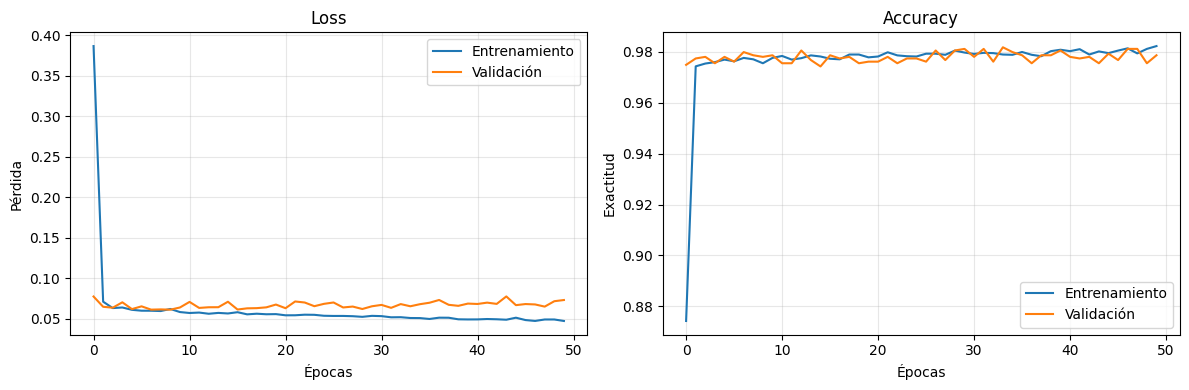

In [63]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar las variables seleccionadas (X_kbest) con Min-Max
scaler_minmax = MinMaxScaler()
X_kbest_norm_array = scaler_minmax.fit_transform(X_kbest)

# Convertir a DataFrame conservando columnas e índice
X_kbest_norm = pd.DataFrame(
    X_kbest_norm_array,
    columns=X_kbest.columns,
    index=X_kbest.index
)

# Persistir el modelo de normalización
joblib.dump(scaler_minmax, "minmax_scaler.joblib")

print("Modelo de normalización guardado en: minmax_scaler.joblib")
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(historial.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
ax[0].plot(hist_df["loss"], label="Entrenamiento")
ax[0].plot(hist_df["val_loss"], label="Validación")
ax[0].set_title("Loss")
ax[0].set_xlabel("Épocas")
ax[0].set_ylabel("Pérdida")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Exactitud
ax[1].plot(hist_df["accuracy"], label="Entrenamiento")
ax[1].plot(hist_df["val_accuracy"], label="Validación")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Épocas")
ax[1].set_ylabel("Exactitud")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Métricas disponibles: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


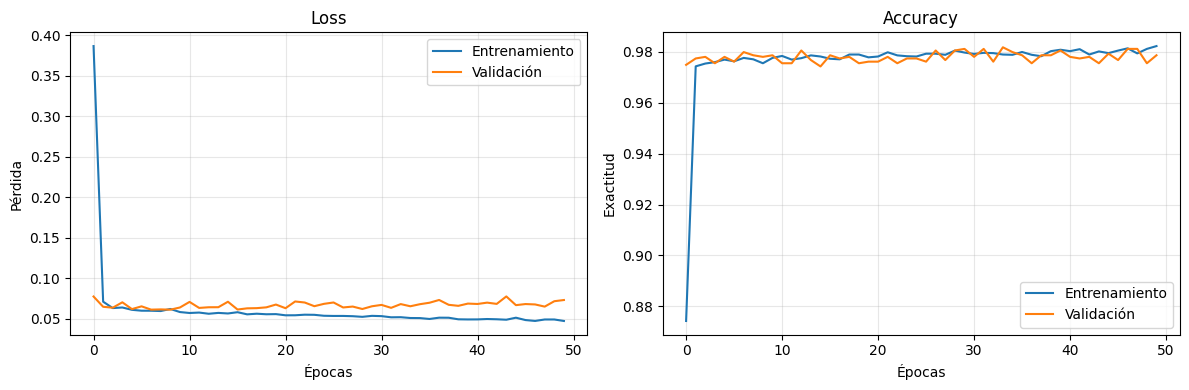

In [64]:
import matplotlib.pyplot as plt
# Mostrar la grafica del history del entrenamiento y con el grafico de loss y de accuracy
print("Métricas disponibles:", list(historial.history.keys()))
hist_df = pd.DataFrame(historial.history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Pérdida
ax[0].plot(hist_df["loss"], label="Entrenamiento")
ax[0].plot(hist_df["val_loss"], label="Validación")
ax[0].set_title("Loss")
ax[0].set_xlabel("Épocas")
ax[0].set_ylabel("Pérdida")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
# Exactitud
ax[1].plot(hist_df["accuracy"], label="Entrenamiento")
ax[1].plot(hist_df["val_accuracy"], label="Validación")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Épocas")
ax[1].set_ylabel("Exactitud")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
       

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


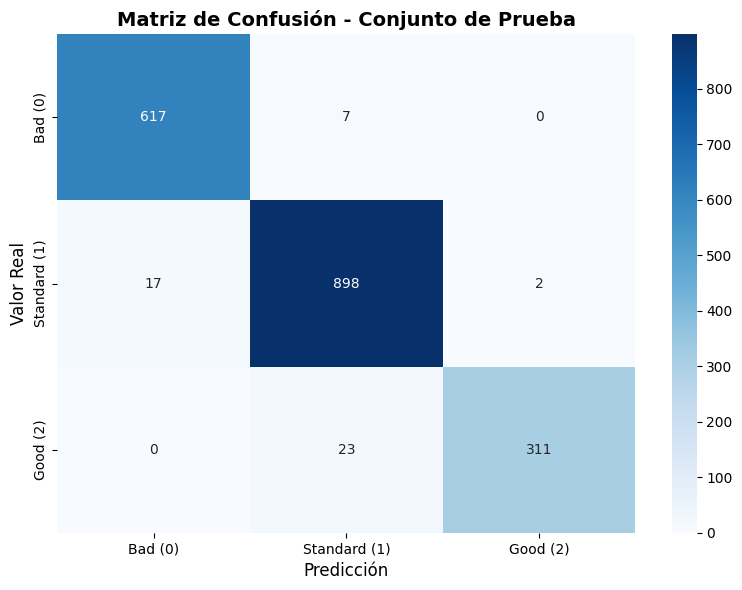

ESTADÍSTICAS DEL MODELO

Reporte de Clasificación:
              precision    recall  f1-score   support

     Bad (0)       0.97      0.99      0.98       624
Standard (1)       0.97      0.98      0.97       917
    Good (2)       0.99      0.93      0.96       334

    accuracy                           0.97      1875
   macro avg       0.98      0.97      0.97      1875
weighted avg       0.97      0.97      0.97      1875

Loss en prueba:     0.0801
Accuracy en prueba: 0.9739 (97.39%)


In [65]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predicciones sobre el conjunto de prueba
y_pred_prob = modelo.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Etiquetas de clases
etiquetas = ['Bad (0)', 'Standard (1)', 'Good (2)']

# Graficar la matriz de confusión con seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=ax
)
ax.set_title('Matriz de Confusión - Conjunto de Prueba', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Estadísticas del modelo
print("=" * 60)
print("ESTADÍSTICAS DEL MODELO")
print("=" * 60)
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=etiquetas))

# Exactitud global
loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)
print(f"Loss en prueba:     {loss:.4f}")
print(f"Accuracy en prueba: {accuracy:.4f} ({accuracy*100:.2f}%)")

In [66]:
ruta_modelo = "modelo_riesgo_credito.keras"
modelo.save(ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")

Modelo guardado en: modelo_riesgo_credito.keras
